In [ ]:
!pip install emnist tqdm

In [ ]:
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import SpectralClustering
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, adjusted_rand_score
import tensorflow as tf
from tensorflow import keras

In [ ]:
import kagglehub
path = kagglehub.dataset_download('crawford/emnist')
print('Path to dataset files:', path)
train_csv = path + '/emnist-letters-train.csv'
test_csv  = path + '/emnist-letters-test.csv'
training_letter = pd.read_csv(train_csv, header=None)
testing_letter  = pd.read_csv(test_csv, header=None)
print('training shape:', training_letter.shape)
print('testing shape: ', testing_letter.shape)

100%|██████████| 1.24G/1.24G [00:11<00:00, 114MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/crawford/emnist/versions/3
training shape: (88800, 785)
testing shape:  (14800, 785)


In [ ]:
# Extract arrays and normalize
y_train_full = np.array(training_letter.iloc[:,0].values)
X_train_full = np.array(training_letter.iloc[:,1:].values, dtype=np.float32)

y_test_full  = np.array(testing_letter.iloc[:,0].values)
X_test_full  = np.array(testing_letter.iloc[:,1:].values, dtype=np.float32)

X_train_full = X_train_full / 255.0
X_test_full  = X_test_full  / 255.0

X_train_full = X_train_full.reshape(-1,28,28,1)
X_test_full  = X_test_full.reshape(-1,28,28,1)

number_of_classes = 37
print('Train images:', X_train_full.shape, 'Train labels:', y_train_full.shape)
print('Test  images:', X_test_full.shape,  'Test  labels:', y_test_full.shape)


Train images: (88800, 28, 28, 1) Train labels: (88800,)
Test  images: (14800, 28, 28, 1) Test  labels: (14800,)


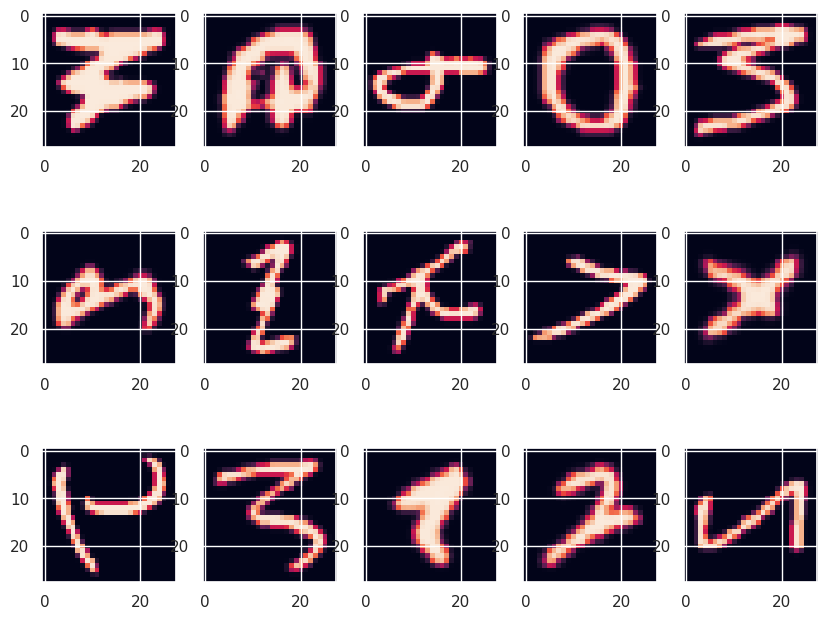

In [ ]:
# FOR VISUALIZATION:
# x1 = np.array(training_letter.iloc[:,1:].values)

import matplotlib.pyplot as plt
fig,axes = plt.subplots(3,5,figsize=(10,8))
for i,ax in enumerate(axes.flat):
    ax.imshow(X_train_full[i].reshape([28,28])) #  get the 28 by 28 pixel'd training examples

In [ ]:
# Create train/val split (consistent for all 4 of my models)
from sklearn.model_selection import train_test_split

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

y_train_split_oh = tf.keras.utils.to_categorical(y_train_split, number_of_classes)
y_val_split_oh   = tf.keras.utils.to_categorical(y_val_split, number_of_classes)

X_train_flat = X_train_split.reshape(X_train_split.shape[0], -1)
X_val_flat   = X_val_split.reshape(X_val_split.shape[0], -1)
X_test_flat  = X_test_full.reshape(X_test_full.shape[0], -1)


print('X_train_split:', X_train_split.shape, 'X_val_split:', X_val_split.shape)
print('X_train_flat:', X_train_flat.shape, 'X_val_flat:', X_val_flat.shape, 'X_test_flat:', X_test_flat.shape)


X_train_split: (71040, 28, 28, 1) X_val_split: (17760, 28, 28, 1)
X_train_flat: (71040, 784) X_val_flat: (17760, 784) X_test_flat: (14800, 784)


In [ ]:
# Logistic Regression

# Scaler is good for logistic regression preprocessing!
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train_flat)
X_val_std   = scaler.transform(X_val_flat)
X_test_std  = scaler.transform(X_test_flat)
print('Training Logistic Regression (might take years)')

log_reg = LogisticRegression(multi_class='multinomial', solver='saga', max_iter=500, n_jobs=5, verbose=1)
log_reg.fit(X_train_std, y_train_split)
y_val_pred_lr = log_reg.predict(X_val_std)
acc_lr_val = accuracy_score(y_val_split, y_val_pred_lr)
print(f'Logistic Regression validation accuracy: {acc_lr_val:.4f}')

# Test evaluation
y_test_pred_lr = log_reg.predict(X_test_std)
acc_lr_test = accuracy_score(y_test_full, y_test_pred_lr)
print(f'Logistic Regression test accuracy: {acc_lr_test:.4f}')
print('\\nClassification report (LogReg, test):')
print(classification_report(y_test_full, y_test_pred_lr, zero_division=0))


NameError: name 'StandardScaler' is not defined

In [ ]:
# Random Forest
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
rf.fit(X_train_flat, y_train_split)
y_val_pred_rf = rf.predict(X_val_flat)
acc_rf_val = accuracy_score(y_val_split, y_val_pred_rf)
print(f'Random Forest validation accuracy: {acc_rf_val:.4f}')


# Test evaluation
y_test_pred_rf = rf.predict(X_test_flat)
acc_rf_test = accuracy_score(y_test_full, y_test_pred_rf)
print(f'Random Forest test accuracy: {acc_rf_test:.4f}')
print('\\nClassification report (RF, test):')
print(classification_report(y_test_full, y_test_pred_rf, zero_division=0))


In [ ]:
# Spectral Clustering (subsample from training split)
print('Running Spectral Clustering on a subsample of the training split...')

SUBSAMPLE = True
if SUBSAMPLE:
  sample_size = 20000 # full size is 71040
  rng = np.random.RandomState(42)
  idx = rng.choice(X_train_flat.shape[0], size=sample_size, replace=False)
  X_sample = X_train_flat[idx]
  y_sample = y_train_split[idx]
else:
  # use the full dataset!
  X_sample = X_train_flat.copy()
  y_sample = y_train_split.copy()


X_sample_std = scaler.transform(X_sample)

spec = SpectralClustering(n_clusters=number_of_classes, affinity='nearest_neighbors', assign_labels='kmeans', random_state=42)
cluster_labels = spec.fit_predict(X_sample_std)

ari_score = adjusted_rand_score(y_sample, cluster_labels)
print(f'Adjusted Rand Index (spectral on training subsample): {ari_score:.4f}')

Running Spectral Clustering on a subsample of the training split...
Adjusted Rand Index (spectral on training subsample): 0.2436


In [ ]:
# FOR CNN:

model = tf.keras.Sequential([
    tf.keras.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64,3, activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(number_of_classes, activation='softmax')
])


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train_split, y_train_split_oh, epochs=10, batch_size=128, validation_data=(X_val_split, y_val_split_oh))
test_eval = model.evaluate(X_test_full, tf.keras.utils.to_categorical(y_test_full, number_of_classes), verbose=1)
print('CNN test loss, test acc:', test_eval)

In [ ]:
# VISUALIZATION:

q = len(history.history['accuracy'])
plt.figure(figsize=(8,5))
sns.lineplot(x=range(1,1+q), y=history.history['accuracy'], label='Train Accuracy')
sns.lineplot(x=range(1,1+q), y=history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.title('CNN Accuracy over epochs'); plt.ylim(0,1)
plt.show()


# Single-point plots for LR, RF, ARI
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
sns.barplot(x=['LogReg'], y=[acc_lr_test]); plt.ylim(0,1); plt.title('LogReg (test acc)')
plt.subplot(1,3,2)
sns.barplot(x=['RandomForest'], y=[acc_rf_test]); plt.ylim(0,1); plt.title('RandomForest (test acc)')
plt.subplot(1,3,3)
sns.barplot(x=['Spectral(ARI)'], y=[ari_score]); plt.ylim(0,1); plt.title('Spectral Clustering (ARI)')
plt.tight_layout(); plt.show()



cnn_test_acc = test_eval[1]
methods = ['CNN (test acc)', 'LogReg (test acc)', 'RF (test acc)', 'Spectral (ARI)']
scores  = [cnn_test_acc, acc_lr_test, acc_rf_test, ari_score]
plt.figure(figsize=(8,5))
sns.barplot(x=methods, y=scores, palette='viridis'); plt.ylim(0,1)
plt.xticks(rotation=15); plt.title('Final comparison on consistent datasets'); plt.show()


# Confusion matrices for LR and RF on test set
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
cm_lr = confusion_matrix(y_test_full, y_test_pred_lr)
sns.heatmap(cm_lr, cmap='Blues', cbar=False); plt.title('LogReg Confusion Matrix (test)'); plt.xlabel('Pred'); plt.ylabel('True')
plt.subplot(1,2,2)
cm_rf = confusion_matrix(y_test_full, y_test_pred_rf)
sns.heatmap(cm_rf, cmap='Greens', cbar=False); plt.title('RandomForest Confusion Matrix (test)'); plt.xlabel('Pred'); plt.ylabel('True')
plt.tight_layout(); plt.show()

In [ ]:
# ALL RESULTS:

cnn_test_acc = test_eval[1]
results = pd.DataFrame({
    'Model': ['CNN', 'LogisticRegression', 'RandomForest', 'SpectralClustering(ARI)'],
    'Score': [cnn_test_acc, acc_lr_test, acc_rf_test, ari_score]
})
results